<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Robust Backtest Statistics
    </h1>
  </div>
</div>

Two backtest statistics that practitioners reach for are fragile. **Maximum
drawdown** is a single extreme order statistic: it is high-variance, not coherent,
and tells you nothing about the *distribution* of drawdowns. The **naive
Sharpe-difference test** assumes returns are i.i.d., so under serial dependence it
rejects far too often.

This notebook shows two robust replacements from `RiskLabAI.backtest`.
**Conditional Expected Drawdown (CED)** (Goldberg-Mahmoud 2017) is the tail mean of
the maximum-drawdown distribution: lower-variance, coherent, and attributable. The
**Ledoit-Wolf bootstrap Sharpe-difference test** (2008) accounts for serial
dependence and heavy tails, so its size is correct where the naive test inflates.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.backtest import conditional_expected_drawdown, sharpe_difference_test

def max_drawdown(returns):
    """Single worst peak-to-trough decline of a cumulative-return path."""
    equity = np.cumsum(returns)
    peak = np.maximum.accumulate(equity)
    return float((peak - equity).max())

## 1. A heavy-tailed return track

Drawdown statistics matter most for fat-tailed, short tracks. We draw daily returns
from a Student-$t$ with 3 degrees of freedom, the regime where the estimator's
variance is the real problem.

In [3]:
rng = np.random.default_rng(0)
sample = rng.standard_t(3, size=500) * 0.01
print(f"sample track: {len(sample)} days, "
      f"max drawdown = {max_drawdown(sample):.3f}, "
      f"CED@0.95 = {conditional_expected_drawdown(sample, horizon=60, alpha=0.95):.3f}")

sample track: 500 days, max drawdown = 0.212, CED@0.95 = 0.186


## 2. Max-drawdown is a high-variance single extreme

Resample many independent heavy-tailed tracks from the same data-generating process
and look at how much each statistic bounces around. Max-drawdown depends on one
worst path, so its spread (coefficient of variation) is large. CED averages the
worst tail of the drawdown distribution, so it is far more stable.

max drawdown : mean=0.437  std=0.218  coef. of variation=0.498
CED@0.95     : mean=0.245  std=0.077  coef. of variation=0.313  (more stable)


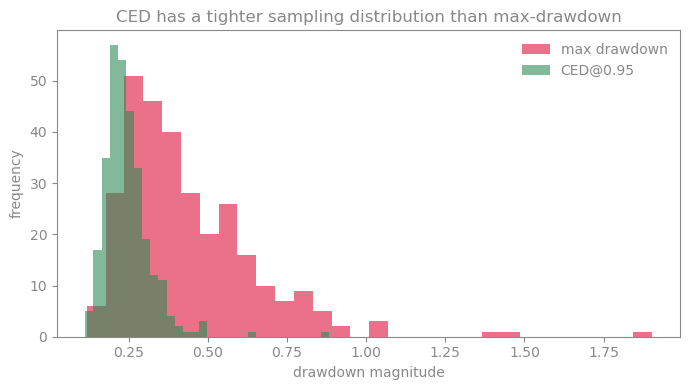

In [4]:
rng = np.random.default_rng(1)
mdd, ced = [], []
for _ in range(300):
    r = rng.standard_t(3, size=500) * 0.01
    mdd.append(max_drawdown(r))
    ced.append(conditional_expected_drawdown(r, horizon=60, alpha=0.95))
mdd, ced = np.array(mdd), np.array(ced)
print(f"max drawdown : mean={mdd.mean():.3f}  std={mdd.std():.3f}  "
      f"coef. of variation={mdd.std()/mdd.mean():.3f}")
print(f"CED@0.95     : mean={ced.mean():.3f}  std={ced.std():.3f}  "
      f"coef. of variation={ced.std()/ced.mean():.3f}  (more stable)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mdd, bins=30, alpha=0.6, label="max drawdown", color="crimson")
ax.hist(ced, bins=30, alpha=0.6, label="CED@0.95", color="seagreen")
ax.set_xlabel("drawdown magnitude"); ax.set_ylabel("frequency")
ax.set_title("CED has a tighter sampling distribution than max-drawdown")
ax.legend()
plt.tight_layout(); plt.show()

## 3. Comparing two Sharpes under serial dependence

A common task is to ask whether strategy A's Sharpe ratio really beats strategy B's.
The **naive** test assumes i.i.d. returns. We run a *size* check: give A and B the
**same** true Sharpe but **positive autocorrelation** (AR(1)), then count how often
each test wrongly reports a significant difference at the 5% level. The naive test
over-rejects; the Ledoit-Wolf bootstrap stays near the nominal 5%.

In [5]:
def ar1_returns(n, phi, seed, mu=0.0003, sigma=0.01):
    r = np.random.default_rng(seed)
    e = r.standard_normal(n) * sigma
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x + mu

n_sims, naive_rej, lw_rej = 150, 0, 0
for s in range(n_sims):
    a = ar1_returns(750, 0.5, s)            # equal true Sharpe, AR(1) dependence
    b = ar1_returns(750, 0.5, s + 10_000)
    naive_rej += sharpe_difference_test(a, b, method="naive")["reject"]
    lw_rej    += sharpe_difference_test(a, b, method="ledoit_wolf",
                                        n_boot=250, random_state=s)["reject"]
print(f"false-positive rate over {n_sims} equal-Sharpe pairs (nominal 0.05):")
print(f"   naive test       : {naive_rej / n_sims:.3f}   (inflated ~3-5x)")
print(f"   Ledoit-Wolf boot : {lw_rej / n_sims:.3f}   (much closer to nominal)")

false-positive rate over 150 equal-Sharpe pairs (nominal 0.05):
   naive test       : 0.260   (inflated ~3-5x)
   Ledoit-Wolf boot : 0.093   (much closer to nominal)


## Takeaways

- **Prefer CED over max-drawdown** as a drawdown-risk statistic: it is the tail mean
  of the drawdown distribution, so it has lower estimator variance and ranks true
  drawdown risk better, most on short, heavy-tailed tracks. The two converge on
  benign returns.
- **Prefer the Ledoit-Wolf bootstrap Sharpe-difference test** when comparing two
  Sharpes under serial dependence or heavy tails: it holds nominal size where the
  naive test over-rejects. The two agree on i.i.d. returns.

`conditional_expected_drawdown` and `sharpe_difference_test` come from
`RiskLabAI.backtest`.